In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd().parent

# Processed data directory
PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DATA_DIR)

Project root: /Users/vs/Sem 5/Respiratory-Disease-Classification
Processed data: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed


In [2]:
patients_df = pd.read_csv(
    PROCESSED_DATA_DIR / "patients_clean.csv"
)

recordings_df = pd.read_csv(
    PROCESSED_DATA_DIR / "recordings_clean.csv"
)

cycles_df = pd.read_csv(
    PROCESSED_DATA_DIR / "cycles_clean.csv"
)

audio_info_df = pd.read_csv(
    PROCESSED_DATA_DIR / "audio_info_clean.csv"
)

print("Patients:", patients_df.shape)
print("Recordings:", recordings_df.shape)
print("Cycles:", cycles_df.shape)
print("Audio info:", audio_info_df.shape)

Patients: (126, 7)
Recordings: (920, 7)
Cycles: (6898, 12)
Audio info: (920, 4)


In [3]:
# ============================================
# PATIENT-LEVEL DISEASE DISTRIBUTION
# ============================================

print("=== DISEASE DISTRIBUTION ===")

disease_counts = (
    patients_df["diagnosis"]
    .value_counts()
)

print(disease_counts)

print("\nDisease percentages:")
disease_percent = (
    patients_df["diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    pd.DataFrame({
        "patients": disease_counts,
        "percentage": disease_percent
    })
)

=== DISEASE DISTRIBUTION ===
diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Pneumonia          6
Bronchiolitis      6
LRTI               2
Asthma             1
Name: count, dtype: int64

Disease percentages:


,patients,percentage
diagnosis,,
COPD,64,50.79
Healthy,26,20.63
URTI,14,11.11
Bronchiectasis,7,5.56
Pneumonia,6,4.76
Bronchiolitis,6,4.76
LRTI,2,1.59
Asthma,1,0.79


In [4]:
# ============================================
# RESPIRATORY SOUND-CLASS DISTRIBUTION
# ============================================

print("=== SOUND CLASS DISTRIBUTION ===")

sound_counts = (
    cycles_df["sound_label"]
    .value_counts()
)

print(sound_counts)

print("\nSound-class percentages:")

sound_percent = (
    cycles_df["sound_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    pd.DataFrame({
        "cycles": sound_counts,
        "percentage": sound_percent
    })
)

=== SOUND CLASS DISTRIBUTION ===
sound_label
Normal      3642
Crackles    1864
Wheezes      886
Both         506
Name: count, dtype: int64

Sound-class percentages:


,cycles,percentage
sound_label,,
Normal,3642,52.80
Crackles,1864,27.02
Wheezes,886,12.84
Both,506,7.34


In [5]:
# ============================================
# DISEASE × SOUND-CLASS RELATIONSHIP
# ============================================

cycles_disease_df = cycles_df.merge(
    patients_df[
        ["patient_id", "diagnosis"]
    ],
    on="patient_id",
    how="left"
)

print("Rows:", len(cycles_disease_df))

print(
    "Missing diagnoses:",
    cycles_disease_df["diagnosis"].isna().sum()
)

Rows: 6898
Missing diagnoses: 0


In [6]:
disease_sound_counts = pd.crosstab(
    cycles_disease_df["diagnosis"],
    cycles_disease_df["sound_label"]
)

print("=== DISEASE × SOUND CLASS ===")

display(disease_sound_counts)

=== DISEASE × SOUND CLASS ===


sound_label,Both,Crackles,Normal,Wheezes
diagnosis,,,,
Asthma,0,0,2,4
Bronchiectasis,10,12,51,31
Bronchiolitis,5,15,76,64
COPD,490,1779,2725,752
Healthy,1,16,303,2
LRTI,0,0,31,1
Pneumonia,0,21,240,24
URTI,0,21,214,8


In [7]:
disease_sound_percent = (
    pd.crosstab(
        cycles_disease_df["diagnosis"],
        cycles_disease_df["sound_label"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("=== DISEASE × SOUND CLASS (%) ===")

display(disease_sound_percent)

=== DISEASE × SOUND CLASS (%) ===


sound_label,Both,Crackles,Normal,Wheezes
diagnosis,,,,
Asthma,0.00,0.00,33.33,66.67
Bronchiectasis,9.62,11.54,49.04,29.81
Bronchiolitis,3.12,9.38,47.50,40.00
COPD,8.53,30.96,47.42,13.09
Healthy,0.31,4.97,94.10,0.62
LRTI,0.00,0.00,96.88,3.12
Pneumonia,0.00,7.37,84.21,8.42
URTI,0.00,8.64,88.07,3.29


In [8]:
# ============================================
# PATIENT-LEVEL SOUND COMPOSITION
# ============================================

patient_sound_counts = pd.crosstab(
    [
        cycles_disease_df["patient_id"],
        cycles_disease_df["diagnosis"]
    ],
    cycles_disease_df["sound_label"]
)

patient_sound_percent = (
    patient_sound_counts
    .div(patient_sound_counts.sum(axis=1), axis=0)
    .mul(100)
)

print("=== PATIENT-LEVEL SOUND COMPOSITION ===")

display(
    patient_sound_percent.head(10)
)

=== PATIENT-LEVEL SOUND COMPOSITION ===


,sound_label,Both,Crackles,Normal,Wheezes
patient_id,diagnosis,,,,
101,URTI,0.000000,0.000000,100.000000,0.000000
102,Healthy,0.000000,0.000000,100.000000,0.000000
103,Asthma,0.000000,0.000000,33.333333,66.666667
104,COPD,0.000000,1.818182,80.000000,18.181818
105,URTI,0.000000,0.000000,100.000000,0.000000
106,COPD,0.000000,44.444444,16.666667,38.888889
107,COPD,13.852814,55.411255,24.675325,6.060606
108,LRTI,0.000000,0.000000,100.000000,0.000000
109,COPD,0.000000,24.590164,75.409836,0.000000


In [9]:
print("Number of patient-level sound profiles:",
      len(patient_sound_percent))

Number of patient-level sound profiles: 126


In [10]:
# ============================================
# DISEASE-LEVEL PATIENT SOUND PROFILE
# ============================================

patient_sound_by_disease = (
    patient_sound_percent
    .reset_index()
    .groupby("diagnosis")[
        ["Both", "Crackles", "Normal", "Wheezes"]
    ]
    .mean()
    .round(2)
)

print("=== AVERAGE PATIENT SOUND COMPOSITION BY DISEASE ===")

display(patient_sound_by_disease)

=== AVERAGE PATIENT SOUND COMPOSITION BY DISEASE ===


sound_label,Both,Crackles,Normal,Wheezes
diagnosis,,,,
Asthma,0.00,0.00,33.33,66.67
Bronchiectasis,3.48,11.57,67.47,17.48
Bronchiolitis,3.03,12.50,46.91,37.56
COPD,7.89,26.05,51.82,14.24
Healthy,0.26,7.17,92.23,0.35
LRTI,0.00,0.00,97.92,2.08
Pneumonia,0.00,9.21,82.23,8.56
URTI,0.00,10.75,84.19,5.07


<Figure size 1100x600 with 0 Axes>

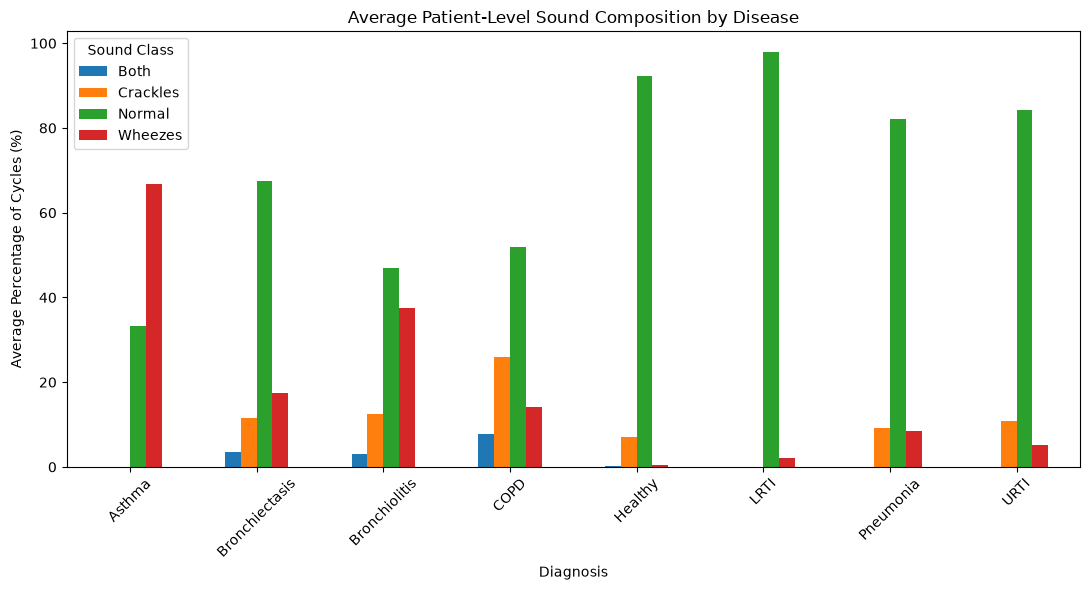

In [11]:
plt.figure(figsize=(11, 6))

patient_sound_by_disease.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Average Patient-Level Sound Composition by Disease")
plt.xlabel("Diagnosis")
plt.ylabel("Average Percentage of Cycles (%)")
plt.xticks(rotation=45)
plt.legend(title="Sound Class")
plt.tight_layout()

plt.show()

In [12]:
# ============================================
# RECORDINGS PER PATIENT
# ============================================

recordings_per_patient = (
    recordings_df
    .groupby("patient_id")
    .size()
)

print("=== RECORDINGS PER PATIENT ===")

print(recordings_per_patient.describe())

print("\nPatients with the fewest recordings:")
display(
    recordings_per_patient
    .sort_values()
    .head(10)
    .reset_index(name="recording_count")
)

print("\nPatients with the most recordings:")
display(
    recordings_per_patient
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="recording_count")
)

=== RECORDINGS PER PATIENT ===
count    126.000000
mean       7.301587
std        9.519050
min        1.000000
25%        1.000000
50%        3.000000
75%        8.000000
max       66.000000
dtype: float64

Patients with the fewest recordings:


,patient_id,recording_count
0,164,1
1,208,1
2,125,1
3,126,1
4,127,1
5,128,1
6,129,1
7,150,1
8,131,1
9,225,1



Patients with the most recordings:


,patient_id,recording_count
0,130,66
1,151,28
2,107,28
3,138,27
4,172,27
5,170,25
6,178,24
7,162,24
8,186,24
9,158,24


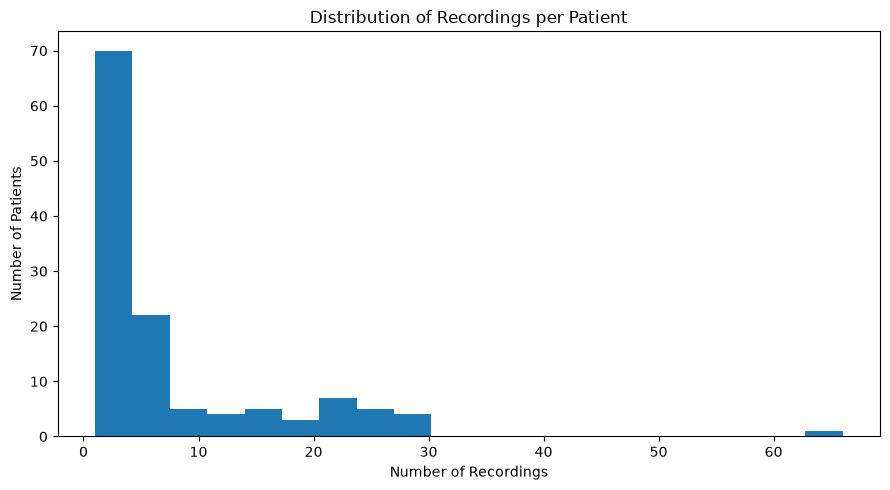

In [13]:
plt.figure(figsize=(9, 5))

recordings_per_patient.plot(
    kind="hist",
    bins=20
)

plt.title("Distribution of Recordings per Patient")
plt.xlabel("Number of Recordings")
plt.ylabel("Number of Patients")
plt.tight_layout()

plt.show()

In [14]:
# ============================================
# PATIENT AGE DISTRIBUTION
# ============================================

print("=== AGE DISTRIBUTION ===")

print(patients_df["age"].describe())

print("\nMissing age values:",
      patients_df["age"].isna().sum())

=== AGE DISTRIBUTION ===
count    125.00000
mean      42.99264
std       32.20907
min        0.25000
25%        4.00000
50%       60.00000
75%       71.00000
max       93.00000
Name: age, dtype: float64

Missing age values: 1


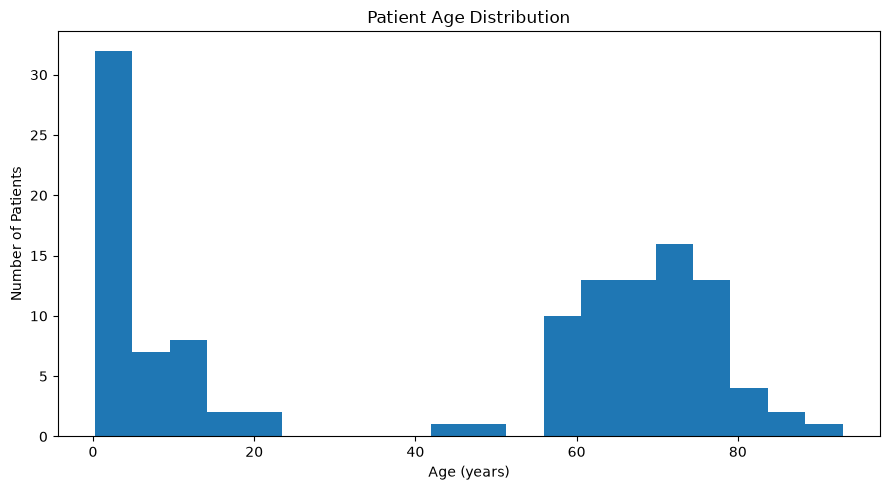

In [15]:
plt.figure(figsize=(9, 5))

patients_df["age"].dropna().plot(
    kind="hist",
    bins=20
)

plt.title("Patient Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.tight_layout()

plt.show()

=== AGE GROUP DISTRIBUTION ===
Child (<18)     49
Adult (>=18)    76
Unknown          1
dtype: int64


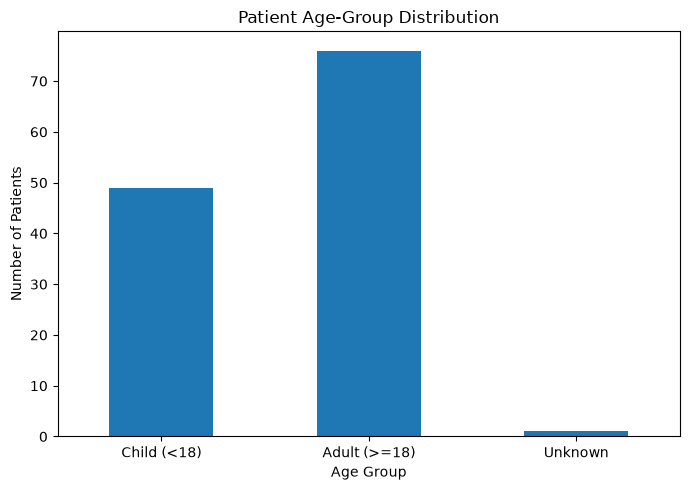

In [16]:
# ============================================
# CHILDREN VS ADULTS
# ============================================

age_group_counts = pd.Series({
    "Child (<18)": (
        (patients_df["age"] < 18)
    ).sum(),

    "Adult (>=18)": (
        (patients_df["age"] >= 18)
    ).sum(),

    "Unknown": (
        patients_df["age"].isna()
    ).sum()
})

print("=== AGE GROUP DISTRIBUTION ===")
print(age_group_counts)

plt.figure(figsize=(7, 5))

age_group_counts.plot(kind="bar")

plt.title("Patient Age-Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [17]:
# ============================================
# SEX × DISEASE
# ============================================

sex_disease = pd.crosstab(
    patients_df["diagnosis"],
    patients_df["sex"],
    dropna=False
)

print("=== SEX × DISEASE ===")

display(sex_disease)

=== SEX × DISEASE ===


sex,F,M,NaN
diagnosis,,,
Asthma,1,0,0
Bronchiectasis,5,2,0
Bronchiolitis,2,4,0
COPD,15,48,1
Healthy,13,13,0
LRTI,0,2,0
Pneumonia,2,4,0
URTI,8,6,0


In [18]:
# ============================================
# SEX × DISEASE
# ============================================

sex_disease = pd.crosstab(
    patients_df["diagnosis"],
    patients_df["sex"],
    dropna=False
)

print("=== SEX × DISEASE ===")

display(sex_disease)

=== SEX × DISEASE ===


sex,F,M,NaN
diagnosis,,,
Asthma,1,0,0
Bronchiectasis,5,2,0
Bronchiolitis,2,4,0
COPD,15,48,1
Healthy,13,13,0
LRTI,0,2,0
Pneumonia,2,4,0
URTI,8,6,0


In [19]:
# ============================================
# CHEST LOCATION DISTRIBUTION
# ============================================

print("=== CHEST LOCATION DISTRIBUTION ===")

location_counts = (
    recordings_df["chest_location"]
    .value_counts()
)

print(location_counts)

print("\nChest-location percentages:")

display(
    location_counts
    .div(location_counts.sum())
    .mul(100)
    .round(2)
    .rename("percentage")
)

=== CHEST LOCATION DISTRIBUTION ===
chest_location
Ar    168
Al    162
Pl    139
Pr    132
Tc    130
Lr    112
Ll     77
Name: count, dtype: int64

Chest-location percentages:


chest_location
Ar    18.26
Al    17.61
Pl    15.11
Pr    14.35
Tc    14.13
Lr    12.17
Ll     8.37
Name: percentage, dtype: float64

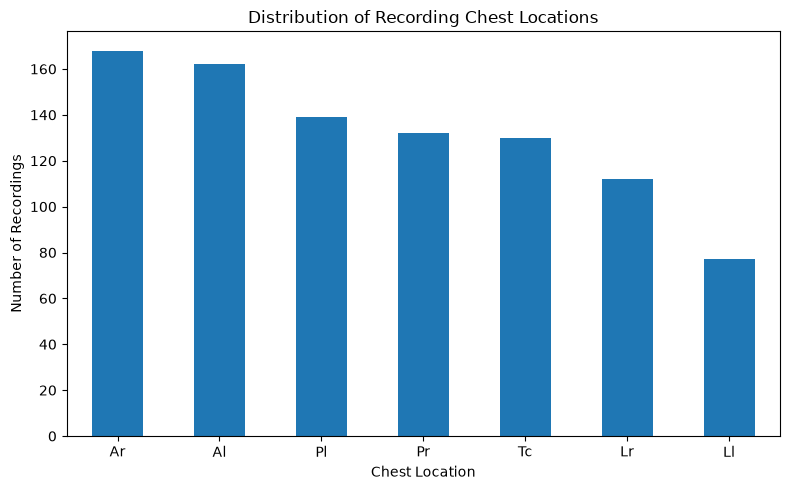

In [20]:
plt.figure(figsize=(8, 5))

location_counts.plot(kind="bar")

plt.title("Distribution of Recording Chest Locations")
plt.xlabel("Chest Location")
plt.ylabel("Number of Recordings")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [21]:
# ============================================
# CHEST LOCATION × DISEASE
# ============================================

recordings_disease_df = recordings_df.merge(
    patients_df[["patient_id", "diagnosis"]],
    on="patient_id",
    how="left"
)

location_disease = pd.crosstab(
    recordings_disease_df["diagnosis"],
    recordings_disease_df["chest_location"]
)

print("=== CHEST LOCATION × DISEASE ===")

display(location_disease)

=== CHEST LOCATION × DISEASE ===


chest_location,Al,Ar,Ll,Lr,Pl,Pr,Tc
diagnosis,,,,,,,
Asthma,0,1,0,0,0,0,0
Bronchiectasis,4,4,1,1,1,1,4
Bronchiolitis,5,1,0,2,4,1,0
COPD,128,140,68,108,125,124,100
Healthy,10,7,3,1,2,2,10
LRTI,1,1,0,0,0,0,0
Pneumonia,7,8,3,0,5,2,12
URTI,7,6,2,0,2,2,4


In [22]:
# ============================================
# ACQUISITION MODE DISTRIBUTION
# ============================================

print("=== ACQUISITION MODE ===")

acquisition_counts = (
    recordings_df["acquisition_mode"]
    .value_counts()
)

print(acquisition_counts)

print("\nPercentages:")

display(
    acquisition_counts
    .div(acquisition_counts.sum())
    .mul(100)
    .round(2)
    .rename("percentage")
)

=== ACQUISITION MODE ===
acquisition_mode
mc    732
sc    188
Name: count, dtype: int64

Percentages:


acquisition_mode
mc    79.57
sc    20.43
Name: percentage, dtype: float64

In [23]:
# ============================================
# EQUIPMENT DISTRIBUTION
# ============================================

print("=== RECORDING EQUIPMENT ===")

equipment_counts = (
    recordings_df["equipment"]
    .value_counts()
)

print(equipment_counts)

print("\nPercentages:")

display(
    equipment_counts
    .div(equipment_counts.sum())
    .mul(100)
    .round(2)
    .rename("percentage")
)

=== RECORDING EQUIPMENT ===
equipment
AKGC417L    646
Meditron    127
LittC2SE     87
Litt3200     60
Name: count, dtype: int64

Percentages:


equipment
AKGC417L    70.22
Meditron    13.80
LittC2SE     9.46
Litt3200     6.52
Name: percentage, dtype: float64

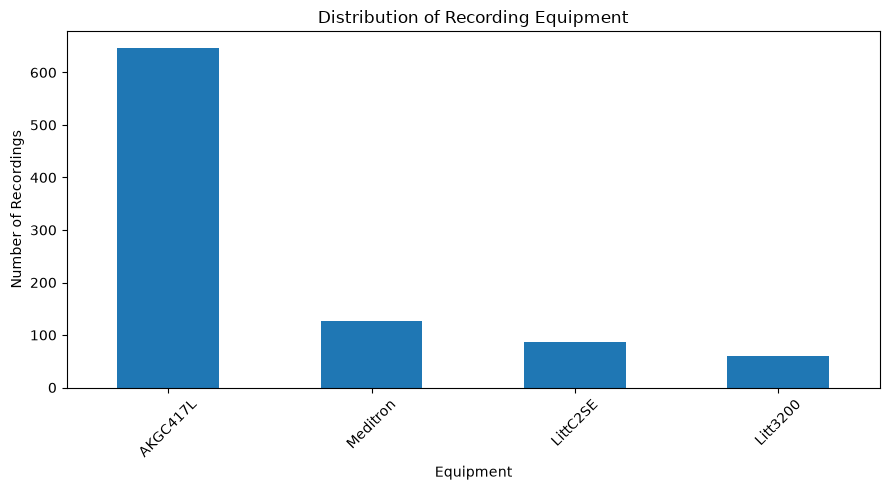

In [24]:
plt.figure(figsize=(9, 5))

equipment_counts.plot(kind="bar")

plt.title("Distribution of Recording Equipment")
plt.xlabel("Equipment")
plt.ylabel("Number of Recordings")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
# ============================================
# EQUIPMENT × ACQUISITION MODE
# ============================================

equipment_acquisition = pd.crosstab(
    recordings_df["equipment"],
    recordings_df["acquisition_mode"]
)

print("=== EQUIPMENT × ACQUISITION MODE ===")

display(equipment_acquisition)

=== EQUIPMENT × ACQUISITION MODE ===


acquisition_mode,mc,sc
equipment,,
AKGC417L,646,0
Litt3200,0,60
LittC2SE,86,1
Meditron,0,127


In [26]:
# ============================================
# SAMPLE-RATE DISTRIBUTION
# ============================================

print("=== SAMPLE RATE DISTRIBUTION ===")

sample_rate_counts = (
    audio_info_df["sample_rate"]
    .value_counts()
    .sort_index()
)

print(sample_rate_counts)

print("\nPercentages:")

display(
    sample_rate_counts
    .div(sample_rate_counts.sum())
    .mul(100)
    .round(2)
    .rename("percentage")
)

=== SAMPLE RATE DISTRIBUTION ===
sample_rate
4000      90
10000      6
44100    824
Name: count, dtype: int64

Percentages:


sample_rate
4000      9.78
10000     0.65
44100    89.57
Name: percentage, dtype: float64

In [27]:
# ============================================
# RECORDING DURATION
# ============================================

print("=== RECORDING DURATION ===")

print(
    audio_info_df["duration"].describe()
)

print("\nDuration percentiles:")

display(
    audio_info_df["duration"]
    .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename("duration_seconds")
)

=== RECORDING DURATION ===
count    920.000000
mean      21.492424
std        8.307421
min        7.856000
25%       20.000000
50%       20.000000
75%       20.000000
max       86.200000
Name: duration, dtype: float64

Duration percentiles:


0.01    14.5760
0.05    20.0000
0.10    20.0000
0.25    20.0000
0.50    20.0000
0.75    20.0000
0.90    20.0000
0.95    25.6512
0.99    68.9500
Name: duration_seconds, dtype: float64

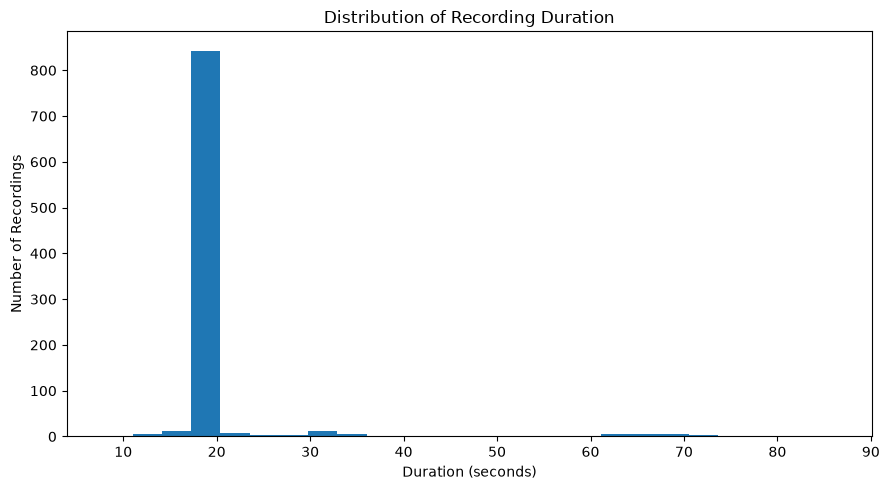

In [28]:
plt.figure(figsize=(9, 5))

audio_info_df["duration"].plot(
    kind="hist",
    bins=25
)

plt.title("Distribution of Recording Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Recordings")
plt.tight_layout()

plt.show()

In [29]:
# ============================================
# SAMPLE RATE × DURATION
# ============================================

sample_duration = audio_info_df.groupby(
    "sample_rate"
)["duration"].describe()

display(sample_duration)

,count,mean,std,min,25%,50%,75%,max
sample_rate,,,,,,,,
4000,90.0,34.376000,22.685991,7.856,17.504,22.992,62.3875,86.200000
10000,6.0,33.333333,0.458984,32.900,32.975,33.200,33.7250,33.900000
44100,824.0,19.999017,0.012564,19.800,20.000,20.000,20.0000,20.000023


In [30]:
# ============================================
# AGE BY DISEASE
# ============================================

print("=== AGE DISTRIBUTION BY DISEASE ===")

disease_age_stats = (
    patients_df
    .groupby("diagnosis")["age"]
    .describe()
    .round(2)
)

display(disease_age_stats)

=== AGE DISTRIBUTION BY DISEASE ===


,count,mean,std,min,25%,50%,75%,max
diagnosis,,,,,,,,
Asthma,1.0,70.00,NaN,70.00,70.00,70.00,70.00,70.0
Bronchiectasis,7.0,48.29,20.62,19.00,35.50,56.00,59.50,73.0
Bronchiolitis,6.0,1.78,1.05,0.67,1.00,1.50,2.75,3.0
COPD,63.0,69.22,8.36,45.00,64.00,69.00,75.00,93.0
Healthy,26.0,6.20,5.28,0.25,2.00,5.00,10.75,16.0
LRTI,2.0,1.79,1.71,0.58,1.18,1.79,2.40,3.0
Pneumonia,6.0,62.33,29.11,4.00,67.00,72.00,77.75,81.0
URTI,14.0,3.98,3.90,0.67,2.00,3.00,4.00,16.0


In [31]:
median_age_by_disease = (
    patients_df
    .groupby("diagnosis")["age"]
    .median()
    .sort_values()
)

print("=== MEDIAN AGE BY DISEASE ===")

display(
    median_age_by_disease.rename("median_age")
)

=== MEDIAN AGE BY DISEASE ===


diagnosis
Bronchiolitis      1.50
LRTI               1.79
URTI               3.00
Healthy            5.00
Bronchiectasis    56.00
COPD              69.00
Asthma            70.00
Pneumonia         72.00
Name: median_age, dtype: float64

<Figure size 1100x600 with 0 Axes>

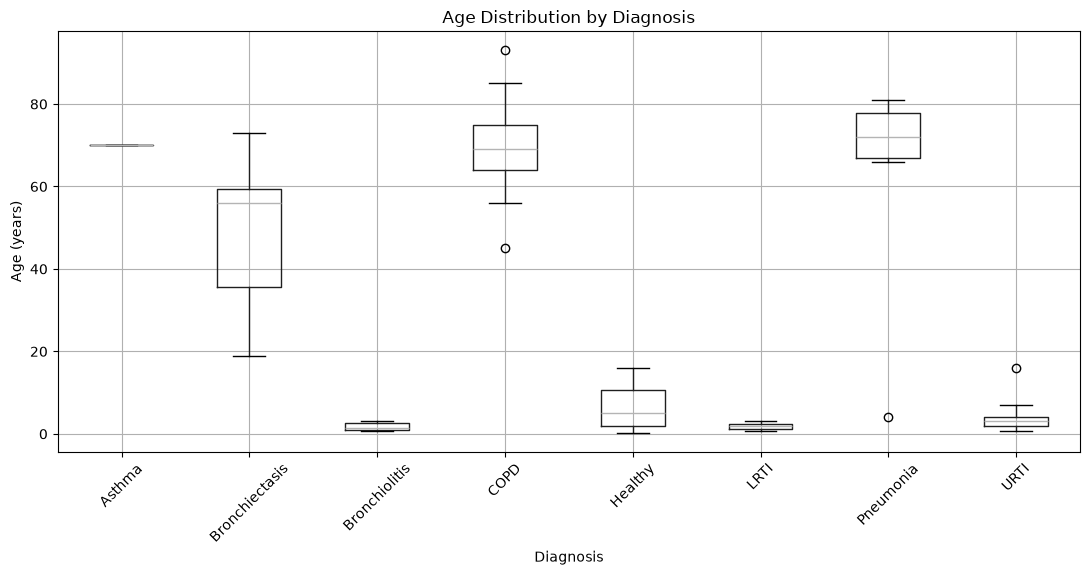

In [32]:
plt.figure(figsize=(11, 6))

patients_df.boxplot(
    column="age",
    by="diagnosis",
    figsize=(11, 6)
)

plt.title("Age Distribution by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Age (years)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [33]:
# ============================================
# DISEASE × SEX COMPOSITION
# ============================================

disease_sex_percent = (
    pd.crosstab(
        patients_df["diagnosis"],
        patients_df["sex"],
        normalize="index",
        dropna=False
    )
    .mul(100)
    .round(2)
)

print("=== DISEASE × SEX (%) ===")

display(disease_sex_percent)

=== DISEASE × SEX (%) ===


sex,F,M,NaN
diagnosis,,,
Asthma,100.00,0.00,0.00
Bronchiectasis,71.43,28.57,0.00
Bronchiolitis,33.33,66.67,0.00
COPD,23.44,75.00,1.56
Healthy,50.00,50.00,0.00
LRTI,0.00,100.00,0.00
Pneumonia,33.33,66.67,0.00
URTI,57.14,42.86,0.00


<Figure size 1000x600 with 0 Axes>

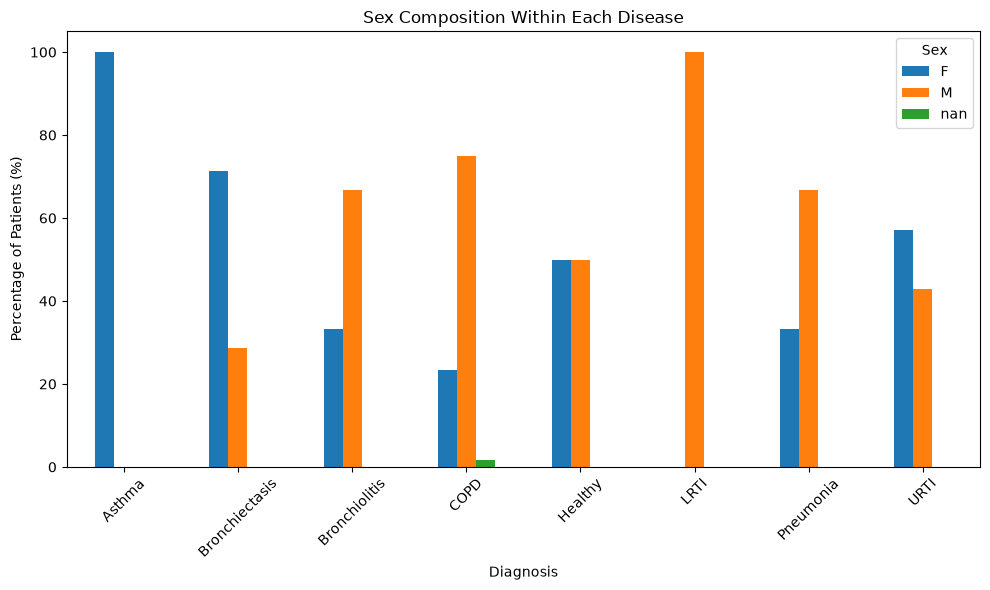

In [34]:
plt.figure(figsize=(10, 6))

disease_sex_percent.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sex Composition Within Each Disease")
plt.xlabel("Diagnosis")
plt.ylabel("Percentage of Patients (%)")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.tight_layout()

plt.show()

In [35]:
# ============================================
# DISEASE × OFFICIAL RECORDING SPLIT
# ============================================

recordings_disease_df = recordings_df.merge(
    patients_df[["patient_id", "diagnosis"]],
    on="patient_id",
    how="left"
)

print("Missing diagnoses:",
      recordings_disease_df["diagnosis"].isna().sum())

Missing diagnoses: 0


In [36]:
split_disease_counts = pd.crosstab(
    recordings_disease_df["diagnosis"],
    recordings_disease_df["official_split"]
)

print("=== DISEASE × OFFICIAL SPLIT ===")

display(split_disease_counts)

=== DISEASE × OFFICIAL SPLIT ===


official_split,test,train
diagnosis,,
Asthma,0,1
Bronchiectasis,2,14
Bronchiolitis,6,7
COPD,349,444
Healthy,17,18
LRTI,0,2
Pneumonia,0,37
URTI,7,16


In [37]:
split_disease_percent = (
    pd.crosstab(
        recordings_disease_df["diagnosis"],
        recordings_disease_df["official_split"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("=== DISEASE × OFFICIAL SPLIT (%) ===")

display(split_disease_percent)

=== DISEASE × OFFICIAL SPLIT (%) ===


official_split,test,train
diagnosis,,
Asthma,0.00,100.00
Bronchiectasis,12.50,87.50
Bronchiolitis,46.15,53.85
COPD,44.01,55.99
Healthy,48.57,51.43
LRTI,0.00,100.00
Pneumonia,0.00,100.00
URTI,30.43,69.57


In [38]:
# ============================================
# PATIENT-LEVEL AUDIO AVAILABILITY
# ============================================

patient_recording_counts = (
    recordings_df
    .groupby("patient_id")
    .size()
    .rename("recording_count")
)

patient_cycle_counts = (
    cycles_df
    .groupby("patient_id")
    .size()
    .rename("cycle_count")
)

patient_audio_summary = (
    patients_df[
        ["patient_id", "diagnosis"]
    ]
    .merge(
        patient_recording_counts,
        on="patient_id",
        how="left"
    )
    .merge(
        patient_cycle_counts,
        on="patient_id",
        how="left"
    )
)

print("=== PATIENT-LEVEL AUDIO SUMMARY ===")

display(
    patient_audio_summary.head(10)
)

=== PATIENT-LEVEL AUDIO SUMMARY ===


,patient_id,diagnosis,recording_count,cycle_count
0,101,URTI,2,23
1,102,Healthy,1,13
2,103,Asthma,1,6
3,104,COPD,6,55
4,105,URTI,1,8
5,106,COPD,2,18
6,107,COPD,28,231
7,108,LRTI,1,8
8,109,COPD,6,61
9,110,COPD,5,52


In [39]:
audio_by_disease = (
    patient_audio_summary
    .groupby("diagnosis")[
        ["recording_count", "cycle_count"]
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("=== AUDIO AVAILABILITY BY DISEASE ===")

display(audio_by_disease)

=== AUDIO AVAILABILITY BY DISEASE ===


recording_count                       cycle_count         \
                         count   mean median min max       count   mean   
diagnosis                                                                 
Asthma                       1   1.00    1.0   1   1           1   6.00   
Bronchiectasis               7   2.29    2.0   1   6           7  14.86   
Bronchiolitis                6   2.17    2.0   1   3           6  26.67   
COPD                        64  12.39    7.5   1  66          64  89.78   
Healthy                     26   1.35    1.0   1   4          26  12.38   
LRTI                         2   1.00    1.0   1   1           2  16.00   
Pneumonia                    6   6.17    4.5   3  13           6  47.50   
URTI                        14   1.64    1.0   1   4          14  17.36   

                                
               median min  max  
diagnosis                       
Asthma            6.0   6    6  
Bronchiectasis   11.0   6   41  
Bronchiolitis    24.5  13   51  
COPD             67.5   5  507  
Healthy          10.5   4   42  
LRTI             16.0   8   24  
Pneumonia        35.5  24  112  
URTI             11.0   4   62

In [40]:
audio_disease_median = (
    patient_audio_summary
    .groupby("diagnosis")[
        ["recording_count", "cycle_count"]
    ]
    .median()
    .sort_values("cycle_count")
)

print("=== MEDIAN AUDIO AVAILABILITY BY DISEASE ===")

display(audio_disease_median)

=== MEDIAN AUDIO AVAILABILITY BY DISEASE ===


,recording_count,cycle_count
diagnosis,,
Asthma,1.0,6.0
Healthy,1.0,10.5
Bronchiectasis,2.0,11.0
URTI,1.0,11.0
LRTI,1.0,16.0
Bronchiolitis,2.0,24.5
Pneumonia,4.5,35.5
COPD,7.5,67.5


In [41]:
# ============================================
# FINAL EDA SUMMARY TABLES
# ============================================

eda_summary = {
    "patients": len(patients_df),
    "recordings": len(recordings_df),
    "respiratory_cycles": len(cycles_df),

    "disease_classes": patients_df["diagnosis"].nunique(),
    "sound_classes": cycles_df["sound_label"].nunique(),

    "children_under_18": (
        patients_df["age"] < 18
    ).sum(),

    "adults_18_or_older": (
        patients_df["age"] >= 18
    ).sum(),

    "unknown_age": (
        patients_df["age"].isna()
    ).sum(),

    "train_recordings": (
        recordings_df["official_split"] == "train"
    ).sum(),

    "test_recordings": (
        recordings_df["official_split"] == "test"
    ).sum(),

    "sample_rates": (
        audio_info_df["sample_rate"].nunique()
    ),

    "chest_locations": (
        recordings_df["chest_location"].nunique()
    ),

    "equipment_types": (
        recordings_df["equipment"].nunique()
    )
}

print("=== FINAL EDA SUMMARY ===")

display(
    pd.DataFrame(
        [eda_summary]
    ).T.rename(columns={0: "value"})
)

=== FINAL EDA SUMMARY ===


,value
patients,126
recordings,920
respiratory_cycles,6898
disease_classes,8
sound_classes,4
children_under_18,49
adults_18_or_older,76
unknown_age,1
train_recordings,539
test_recordings,381


In [42]:
# ============================================
# SAVE EDA TABLES
# ============================================

EDA_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed" / "eda"
)

EDA_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

disease_counts.to_csv(
    EDA_DATA_DIR / "disease_distribution.csv"
)

sound_counts.to_csv(
    EDA_DATA_DIR / "sound_distribution.csv"
)

disease_sound_counts.to_csv(
    EDA_DATA_DIR / "disease_sound_counts.csv"
)

disease_sound_percent.to_csv(
    EDA_DATA_DIR / "disease_sound_percent.csv"
)

patient_sound_by_disease.to_csv(
    EDA_DATA_DIR / "patient_sound_by_disease.csv"
)

patient_audio_summary.to_csv(
    EDA_DATA_DIR / "patient_audio_summary.csv",
    index=False
)

print("EDA tables saved to:")
print(EDA_DATA_DIR)

EDA tables saved to:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/eda


In [ ]:
# Final EDA Findings

## 1. Dataset Overview

The exploratory data analysis was performed on the cleaned and validated ICBHI respiratory sound dataset.

The dataset contains:

- **126 patients**
- **920 respiratory recordings**
- **6,898 annotated respiratory cycles**
- **8 diagnosis categories**
- **4 respiratory sound categories**
- **3 different sampling rates**
- **7 chest recording locations**
- **4 recording equipment types**

The dataset follows a hierarchical structure:

**Patient → Recording → Respiratory Cycle**

This hierarchy is preserved throughout the analysis.

---

## 2. Patient-Level Disease Distribution

The patient-level diagnosis distribution is highly imbalanced.

| Diagnosis | Patients | Percentage |
|---|---:|---:|
| COPD | 64 | 50.79% |
| Healthy | 26 | 20.63% |
| URTI | 14 | 11.11% |
| Bronchiectasis | 7 | 5.56% |
| Pneumonia | 6 | 4.76% |
| Bronchiolitis | 6 | 4.76% |
| LRTI | 2 | 1.59% |
| Asthma | 1 | 0.79% |

COPD represents approximately half of all patients, while Asthma and LRTI have very few patients.

This imbalance is important for the later disease-classification task. Accuracy alone will not be sufficient for evaluating the models. Macro F1-score, balanced accuracy, class-wise precision/recall, and confusion matrices should also be considered.

---

## 3. Respiratory Sound-Class Distribution

At the respiratory-cycle level, four sound classes are present:

| Sound Class | Cycles | Percentage |
|---|---:|---:|
| Normal | 3,642 | 52.80% |
| Crackles | 1,864 | 27.02% |
| Wheezes | 886 | 12.84% |
| Both | 506 | 7.34% |

Normal respiratory cycles are the majority class, followed by Crackles, Wheezes, and Both.

Therefore, the sound-classification task also contains class imbalance, which should be considered during model training and evaluation.

---

## 4. Disease and Respiratory Sound Relationship

The analysis shows that respiratory sound composition differs across diagnoses.

For example:

- Healthy patients have a very high proportion of Normal cycles.
- COPD has a relatively high proportion of Crackles and Both sounds.
- Bronchiolitis contains a relatively high proportion of Wheezes.
- Asthma contains a high proportion of Wheezes in this dataset.
- Pneumonia and URTI contain predominantly Normal cycles.

However, these observations **must not be interpreted as evidence that a particular sound directly determines a disease**.

The diagnosis is a **patient-level label**, while the respiratory sound annotation is a **cycle-level label**. Patients also contribute different numbers of recordings and cycles.

Therefore, respiratory sound labels should be treated as informative observations rather than direct disease labels.

---

## 5. Patient-Level Sound Composition

To account for the patient-level nature of disease diagnosis, the sound annotations were aggregated for each patient.

A total of **126 patient-level sound profiles** were obtained.

Each patient can contain a mixture of:

- Normal
- Crackles
- Wheezes
- Both

The average patient-level sound composition also differs between diagnoses.

For example:

- Healthy patients have a high average proportion of Normal cycles.
- COPD patients have higher average proportions of Crackles and Both compared with Healthy patients.
- Bronchiolitis has a relatively high average proportion of Wheezes.
- Asthma shows a high Wheeze proportion in this dataset.

However, disease groups with very few patients must be interpreted cautiously. In particular, Asthma contains only one patient and LRTI contains only two patients.

These patient-level sound profiles support the use of an aggregation-based approach for disease classification.

---

## 6. Recordings per Patient

The number of recordings varies substantially between patients.

The observed range is:

- Minimum: **1 recording**
- Median: **3 recordings**
- Mean: **7.30 recordings**
- Maximum: **66 recordings**

Similarly, the number of respiratory cycles varies substantially between patients.

This means that different patients contribute different amounts of available audio.

For disease classification, patients with many recordings should not automatically receive disproportionately greater influence simply because more recordings were collected.

This supports the use of patient-level aggregation or a Multiple Instance Learning (MIL)-style approach in the later disease-classification stage.

---

## 7. Age Distribution

Age is available for **125 of the 126 patients**.

The observed age statistics are:

- Minimum: **0.25 years**
- Mean: **42.99 years**
- Median: **60 years**
- Maximum: **93 years**

The dataset contains:

- **49 children (<18 years)**
- **76 adults (≥18 years)**
- **1 patient with unknown age**

Decimal ages were preserved as provided because they provide useful precision for very young children.

The missing demographic information for patient 223 was not imputed during cleaning.

---

## 8. Disease and Age Relationship

The age distribution differs considerably between diagnosis groups.

The median ages include:

| Diagnosis | Median Age |
|---|---:|
| Bronchiolitis | 1.50 |
| LRTI | 1.79 |
| URTI | 3.00 |
| Healthy | 5.00 |
| Bronchiectasis | 56.00 |
| COPD | 69.00 |
| Asthma | 70.00 |
| Pneumonia | 72.00 |

This indicates that several diagnoses in the dataset are strongly concentrated in particular age ranges.

However, these observations are descriptive and should not be interpreted as causal relationships. Some diagnosis groups contain very few patients.

---

## 9. Sex Distribution

The dataset contains:

- **79 male patients**
- **46 female patients**
- **1 patient with missing sex information**

The sex composition varies across diagnosis groups.

For example, COPD contains a higher proportion of male patients, while Healthy patients have an approximately equal male/female distribution.

Because some diagnosis groups have very small sample sizes, these differences should be treated as descriptive observations rather than general population-level conclusions.

---

## 10. Chest-Location Distribution

The recordings were collected from seven chest locations:

| Location | Recordings | Percentage |
|---|---:|---:|
| Ar | 168 | 18.26% |
| Al | 162 | 17.61% |
| Pl | 139 | 15.11% |
| Pr | 132 | 14.35% |
| Tc | 130 | 14.13% |
| Lr | 112 | 12.17% |
| Ll | 77 | 8.37% |

All seven expected ICBHI chest locations are represented.

The distribution is not perfectly uniform, so chest location may contribute to variation in recorded acoustic characteristics.

---

## 11. Acquisition Mode and Recording Equipment

Two acquisition modes are present:

- **mc:** 732 recordings (79.57%)
- **sc:** 188 recordings (20.43%)

Four equipment types are present:

| Equipment | Recordings | Percentage |
|---|---:|---:|
| AKGC417L | 646 | 70.22% |
| Meditron | 127 | 13.80% |
| LittC2SE | 87 | 9.46% |
| Litt3200 | 60 | 6.52% |

The dataset is therefore acoustically heterogeneous.

The equipment and acquisition-mode distributions are also not independent; for example, AKGC417L recordings are all associated with `mc`, while Litt3200 and Meditron recordings are associated with `sc`.

This heterogeneity is important because later feature-extraction and machine-learning methods could potentially learn recording-device characteristics in addition to respiratory information.

Therefore, equipment and acquisition mode should be considered during later analysis.

---

## 12. Sampling Rate Distribution

Three sampling rates are present:

| Sampling Rate | Recordings | Percentage |
|---|---:|---:|
| 4,000 Hz | 90 | 9.78% |
| 10,000 Hz | 6 | 0.65% |
| 44,100 Hz | 824 | 89.57% |

The majority of recordings use 44.1 kHz, while a smaller number use 4 kHz and 10 kHz.

The original sampling rates were preserved during EDA and cleaning.

Resampling will be handled separately during the audio-preprocessing stage so that the preprocessing decision is explicit and reproducible.

---

## 13. Recording Duration

Recording duration varies across the dataset.

The observed statistics are:

- Minimum: **7.856 seconds**
- Mean: **21.49 seconds**
- Median: **20 seconds**
- Maximum: **86.20 seconds**

The 44.1-kHz recordings are almost uniformly around 20 seconds, whereas the 4-kHz recordings show substantially greater duration variation.

This confirms that the dataset contains heterogeneous recording lengths.

Later audio preprocessing will therefore need a consistent strategy for handling different recording and respiratory-cycle durations.

---

## 14. Official Train/Test Split

The official ICBHI split contains:

- **539 training recordings**
- **381 test recordings**

The exploratory analysis shows that the distribution of diagnoses across the official recording-level split is not uniform.

For example, Asthma, LRTI, and Pneumonia have no recordings in the official test partition.

Therefore, the official recording-level split should **not be directly used as the disease-classification evaluation split**.

For patient-level disease classification, the project will use a **patient-level split**, ensuring that all recordings and respiratory cycles belonging to a patient remain in the same partition.

This is necessary to prevent patient-level information leakage.

---

## 15. Patient-Level Audio Availability by Disease

The amount of audio available per patient differs substantially between diagnosis groups.

For example:

- COPD patients have a median of **7.5 recordings** and **67.5 cycles**.
- Healthy patients have a median of **1 recording** and **10.5 cycles**.
- Pneumonia patients have a median of **4.5 recordings** and **35.5 cycles**.
- Asthma has only **1 patient**, with 1 recording and 6 cycles.

This demonstrates that disease groups do not have equal amounts of audio evidence.

This is an important consideration for patient-level disease classification and supports an aggregation/MIL-based strategy where multiple recordings or cycles can contribute to a single patient-level prediction.

---

# Overall EDA Conclusions

The EDA identified several important characteristics of the ICBHI dataset:

1. **Strong disease-class imbalance** exists at the patient level.
2. **Sound-class imbalance** exists at the respiratory-cycle level.
3. Patients contain different mixtures of respiratory sound types.
4. The number of recordings and cycles varies substantially between patients.
5. The dataset contains both children and adults with a wide age range.
6. Several disease groups are strongly associated with particular age ranges within this dataset, although these relationships are descriptive.
7. Recordings come from multiple chest locations, acquisition modes, and equipment types.
8. The dataset contains three different sampling rates and substantial variation in recording duration.
9. The official ICBHI split is recording-level and is not appropriate as the sole evaluation strategy for patient-level disease classification.
10. Patient-level splitting is required for disease classification to prevent patient leakage.
11. These findings support treating **sound classification and disease classification as two related but distinct tasks**.

## Project Direction After EDA

The findings guide the next stages of the project:

### Sound Classification

**Respiratory cycle → Normal / Crackles / Wheezes / Both**

The cycle annotations will be used as the target for sound classification.

### Disease Classification

**Patient → Diagnosis**

Multiple recordings and respiratory cycles from the same patient will be aggregated to predict the patient-level diagnosis.

### Data Mining

The extracted acoustic features will subsequently be explored using:

- descriptive statistics
- dimensionality reduction
- clustering
- feature relationships
- other appropriate data-mining techniques

### Audio Preprocessing

The next stage will address:

- common sampling rate
- respiratory-cycle extraction
- signal normalization/preprocessing
- handling variable cycle lengths
- preparation of data for feature extraction and machine learning

The EDA stage therefore establishes the statistical and structural understanding required before performing audio preprocessing, feature engineering, data mining, and predictive modeling.